# Instalación e importación de librerías

In [1]:
!pip install tqdm imageio scikit-image opencv-python matplotlib numpy

import os
import sys
import torch

!pip install fvcore iopath
!pip install 'git+https://github.com/facebookresearch/pytorch3d.git@main'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=8cf14fc292a0cf2667c6ee889f31c060385ff0e402fee5f34a96a8fc9594fda5
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=0c5bef7c2ad29f3fbd6360f445f45c3989dcdd1d88e085310f28b594bd7c3230
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath
  Cloning https://github.com/facebookresearch/pytorch3d.git (to revision main) to /tmp/pip-req-build-bz9v55ks
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresea

In [2]:
import glob
import numpy as np
from tqdm import tqdm
import imageio
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from skimage import img_as_ubyte
from pytorch3d.utils import ico_sphere
import argparse

# io utils
from pytorch3d.io import load_obj, save_obj
from pytorch3d.ops import cubify

# datastructures
from pytorch3d.structures import Meshes, Volumes

# 3D transformations functions
from pytorch3d.transforms import Rotate, Translate

import random

# rendering components
from pytorch3d.renderer import (
    FoVPerspectiveCameras,
    FoVOrthographicCameras,
    VolumeRenderer,
    NDCGridRaysampler,
    EmissionAbsorptionRaymarcher,
    look_at_view_transform,
    TexturesVertex
)

from pytorch3d.loss import (
    chamfer_distance,
    mesh_edge_loss,
    mesh_laplacian_smoothing,
    mesh_normal_consistency,
)

import cv2
from utills import (get_voxel_renderer,get_phong_renderer, create_cameras, create_cameras_TFS_mode, create_cameras_4VTFS_mode, render_voxels)

from datasets import load_data, load_data_from_list
from losses import (huber, silh_loss, MS_SSIM, l1_loss, iou_np, dice_np)
from models import VolumeModel


# Función de entrenamiento

In [3]:
def train():

    global exp_sample_id
    #############################################################
    #             Setting the rendering parameters              #
    #############################################################

    if TFS_mode:
        cameras, Rs, Ts = create_cameras_TFS_mode(device, zdist, mirror_mode, camera_mode)
    elif FourVTSF_mode:
        cameras, Rs, Ts = create_cameras_4VTFS_mode(device, zdist, mirror_mode, camera_mode)
    else:
        cameras, Rs, Ts = create_cameras(num_views, device, zdist, camera_mode, mirror_mode)

    renderer = get_voxel_renderer(device, cameras, img_size, volume_extent_world)
    phong_renderer = get_phong_renderer(device, FoVOrthographicCameras(device=device), img_size)

    i = 0

    print("Experiment:",main_exp_id+sub_exp_id)
    print("Sample : ",i)

    try:
        os.mkdir(root_dir+main_exp_id)
    except:
        print("Directory already exists")

    try:
        os.mkdir(root_dir+main_exp_id+sub_exp_id)
    except:
        print("Directory already exists")

    output_vid_path = root_dir+main_exp_id+sub_exp_id+"/sample_%d_vid.gif"%i
    print(output_vid_path)
    writer = imageio.get_writer(output_vid_path, mode='I', duration=0.1)

    silhs, silhs_tensors = load_data_from_list(shadow_files,
            mirror_mode,
            (img_size, img_size),
            device,
            num_views,
            debug_mode
            )

    volume_size = 128 # Voxel Resolution
    volume_model = VolumeModel(
        renderer,
        volume_size=[volume_size] * 3,
        voxel_size = volume_extent_world / volume_size,
        thresh_density = thresh_density
    ).to(device)

    optimizer = torch.optim.Adam(volume_model.parameters(), lr=lr)
    batch_size = 1

    loop = tqdm(range(Niter))
    # loop = range(Niter)

    ms_ssim_list = []

    # for i in loop:
    for iteration in loop:
        print(iteration)

        # In case we reached the last 75% of iterations,
        # decrease the learning rate of the optimizer 10-fold.
        if iteration == round(Niter * 0.75):
            print('Decreasing LR 10-fold ...')
            optimizer = torch.optim.Adam(
                volume_model.parameters(), lr=lr * 0.1
            )

        # Sample random batch indices.
        # batch_idx = torch.randperm(len(cameras))[:batch_size]
        # print(len(cameras))
        for batch_idx in range(len(cameras)):

            # Zero the optimizer gradient.
            optimizer.zero_grad()

            if camera_mode == "ortho":
                batch_cameras = FoVOrthographicCameras(
                    R = cameras.R[batch_idx].unsqueeze(0),
                    T = cameras.T[batch_idx].unsqueeze(0),
                    znear = cameras.znear[batch_idx].unsqueeze(0),
                    zfar = cameras.zfar[batch_idx].unsqueeze(0),
                    device = device,
                )
            else:
                batch_cameras = FoVPerspectiveCameras(
                    R = cameras.R[batch_idx].unsqueeze(0),
                    T = cameras.T[batch_idx].unsqueeze(0),
                    znear = cameras.znear[batch_idx].unsqueeze(0),
                    zfar = cameras.zfar[batch_idx].unsqueeze(0),
                    device = device,
                )

            # Evaluate the volumetric model.
            rendered_images, rendered_silhouettes = volume_model(
                batch_cameras
            ).split([3, 1], dim=-1)

            pred_output = rendered_images[0][:,:,0]

            sil_err = silh_loss(
                pred_output, silhs_tensors[batch_idx],
            )

            l1_err = l1_loss(
                pred_output.view(1,img_size,img_size).type(torch.float32).to(device),
                silhs_tensors[batch_idx].view(1,img_size,img_size).type(torch.float32).to(device)
            )

            ms_ssim_err = ms_ssim_loss(
                pred_output.view(1,1,img_size,img_size).type(torch.float32).to(device),
                silhs_tensors[batch_idx].view(1,1,img_size,img_size).type(torch.float32).to(device)
            )

            loss = sil_err *silh_wt + l1_err*l1_wt + ms_ssim_err*ms_ssim_wt

            if iteration%10 == 0:
                print(
                        f'Iteration {iteration:04d}:'
                        + f' loss = {float(loss):1.2e}'
                    )

            # Take the optimization step.
            loss.backward()
            optimizer.step()
            silh_pth = root_dir + main_exp_id + sub_exp_id + "/sample_%dview_%d_silh.png"%(exp_sample_id,batch_idx)
            silh_view_img = (pred_output.detach().cpu().numpy()*255).astype(np.uint8)
            ret, silh_view_img = cv2.threshold(silh_view_img,np.max(silh_view_img)*0.8,255,cv2.THRESH_BINARY)
            cv2.imwrite(silh_pth,silh_view_img)

            ms_ssim_list.append(ms_ssim_err.item())

        if iteration%10 == 0:
            print(
                    f'Iteration {iteration:04d}:'
                    + f' loss = {float(loss):1.2e}'
                )
            R, T = look_at_view_transform(zdist, 0, iteration, device=device)
            volumes = Volumes(
                densities = volume_model.voxels[None].expand(
                    batch_size, *volume_model.log_densities.shape),
                features = volume_model.colors[None].expand(
                    batch_size, *volume_model.log_colors.shape),
                voxel_size=volume_model._voxel_size,
            )
            image, silhouette = renderer(cameras=FoVOrthographicCameras(R=R, T=T, device=device), volumes=volumes)[0].split([3, 1], dim=-1)
            image = image[0, ..., :3].detach().squeeze().cpu().numpy()
            image = img_as_ubyte(image)
            writer.append_data(image)

    writer.close()

    mesh1 = cubify(volume_model.voxels,thresh_density)
    final_verts = mesh1.verts_packed()
    final_faces = mesh1.faces_packed()

    # # Store the predicted mesh using save_obj
    final_obj_pth = root_dir + main_exp_id + sub_exp_id +"/sample_%d_output.obj"%exp_sample_id
    final_voxel_pth = root_dir + main_exp_id + sub_exp_id +"/sample_%d_final_voxels.npy"%exp_sample_id

    save_obj(final_obj_pth, final_verts, final_faces)

    voxels = volume_model.voxels.detach().cpu().numpy()
    colors = volume_model.colors.detach().cpu().numpy()

    with open(final_voxel_pth, 'wb') as f:
        np.save(f,voxels)

    folder_pth = root_dir + main_exp_id + sub_exp_id
    for i, img in enumerate(silhs):
        cv2.imwrite(folder_pth+"/sample_%dview_%d.png"%(exp_sample_id,i),img)

    if debug_mode:
        with open(final_voxel_pth, 'rb') as f:
            voxels = np.load(f)
        render_voxels(voxels, volume_extent_world, volume_size, zdist, renderer, device)

    ms_ssim_metric = 1 - np.array(ms_ssim_list).mean()

    mean_iou = 0.0
    mean_dice = 0.0
    for idx in range(num_views*(1+mirror_mode)):

        gt_shadow = cv2.imread(folder_pth+"/sample_%dview_%d.png"%(exp_sample_id,idx),0)
        pred_shadow = cv2.imread(folder_pth+"/sample_%dview_%d_silh.png"%(exp_sample_id,idx),0)
        diff_img = np.abs(gt_shadow - pred_shadow)

        mean_iou+= iou_np(gt_shadow,pred_shadow)
        mean_dice+= dice_np(gt_shadow, pred_shadow)

        gt_shadow = cv2.bitwise_not(gt_shadow)
        pred_shadow = cv2.bitwise_not(pred_shadow)

        cv2.imwrite(folder_pth+"/SHADOW_GT%d_view_%d.png"%(exp_sample_id,idx),gt_shadow)
        cv2.imwrite(folder_pth+"/SHADOW_PRED%d_view_%d.png"%(exp_sample_id,idx),pred_shadow)
        cv2.imwrite(folder_pth+"/SHADOW_DIFF%d_view_%d.png"%(exp_sample_id,idx),diff_img)



    mean_iou = mean_iou/(1.0*num_views*(1+mirror_mode))
    mean_dice = mean_dice/(1.0*num_views*(1+mirror_mode))

    text = ""
    text += "\nEdge loss : " + str(mesh_edge_loss(mesh1).item())
    text += "\nLaplacian loss : " + str(mesh_laplacian_smoothing(mesh1).item())
    text += "\nNormal loss : " + str(mesh_normal_consistency(mesh1).item())
    text += "\nIOU metric: " + str(mean_iou)
    text += "\nDice metric: " + str(mean_dice)
    text += "\nMISSIM metric: " + str(ms_ssim_metric)

    text_file = open(folder_pth+"/log.txt", "w")
    n = text_file.write(cmd_input + text)
    text_file.close()

    exp_sample_id+=1

# Inputs y ejecución

In [4]:
parser = argparse.ArgumentParser(description = "List of various parameters for experiments")
parser.add_argument("device", type=str, help="GPU number")
parser.add_argument("sub_exp_id", type=str, help="sub experiment id")
parser.add_argument("Niter", type=int, help="Number of iterations")
parser.add_argument("lr", type=float, help="Learning rate")

parser.add_argument("-vfl","--views_file_name", type=str, help="Name of file containing path to ground truth views",default="dataset1.txt")
parser.add_argument("-mr","--mirror_mode", type=bool, help="Mirror mode set to true if front and rear both views are to be regressed", default=0)
parser.add_argument("-mr2","--mirror_mode_2", type=bool, help="Mirror mode set to true if front and rear both views are to be regressed", default=0)
parser.add_argument("-tsf","--TSF_mode", type=bool, help="set true for Top-Side-Front view 3 view setup", default=0)
parser.add_argument("-tsf4","--TSF4V_mode", type=bool, help="set true for TSF with three side view setup", default=0)
parser.add_argument("-cam","--camera_mode", type=str, help="set camera mode as ortho or perspective", default="ortho")
parser.add_argument("-imsz","--img_size", type=int, help="set image size",default=512)
parser.add_argument("-swt","--silh_wt", type=float, help="Silhoutte loss weight", default=10.0)
parser.add_argument("-l1wt","--l1_wt", type=float, help="L1 loss weight", default=10.0)
parser.add_argument("-mwt","--ms_ssim_wt", type=float, help="MS_SSIM loss weight", default=0.0)
parser.add_argument("-ns","--num_samples", type=int, help="Number of samples", default=1)
parser.add_argument("-th","--thresh_density", type=float, help="Cubify function threshold", default=0.05)
parser.add_argument("-zd","--zdist", type=float, help="Cubify function threshold", default=1.7)
parser.add_argument("-sdlist", "--shadow_files", nargs="+", default=["None"])

args = parser.parse_args([
    "cuda:0",
    "output1",
    "500",                       # Iteraciones completas
    "0.01",                     # Learning rate preciso para voxeles
    "-imsz", "128",
    "-swt", "10.0",
    "-l1wt", "10.0",
    "-sdlist", "puma.png", "mikey.png"
])

In [5]:
#############################################################
#                 Experiment Key Parameters                 #
#############################################################

# setting Device
if torch.cuda.is_available() and (args.device != "cpu"):
    device = torch.device(args.device)
    torch.cuda.set_device(device)
else:
    device = torch.device("cpu")

print("Device: ", device)

ms_ssim_loss = MS_SSIM(device)

random.seed(43)
root_dir = "/"
main_exp_id = "voxel_results/"

sub_exp_id = args.sub_exp_id
file_name = args.views_file_name
mirror_mode = False
FourVTSF_mode = False
mirror_mode_2 = False # Make it false to get cameras as mirror view but rear view as not a mirror view but other obj view
thresh_density = args.thresh_density
TFS_mode = False
camera_mode = args.camera_mode
img_size = args.img_size
Niter = args.Niter
zdist = args.zdist
debug_mode = False
num_samples = args.num_samples
volume_extent_world = 1.7
exp_sample_id = 0
lr = args.lr
l1_wt = args.l1_wt
silh_wt = args.silh_wt
ms_ssim_wt = args.ms_ssim_wt
shadow_files = args.shadow_files
num_views = len(shadow_files)


cmd_input = "The command line input string \n"+str(sys.argv)

train()

# python train.py cuda:1 temp_trial 30 0.01 -swt 10.0 -l1wt 10.0 -mwt 0.0 -ns 2
# python val.py cuda:0 output1 600 0.01 -swt 10.0 -l1wt 10.0 -sdlist duck.png mikey.png

Device:  cuda:0
Experiment: voxel_results/output1
Sample :  0
/voxel_results/output1/sample_0_vid.gif


  0%|          | 0/500 [00:00<?, ?it/s]

0


/tmp/ipykernel_9686/3544796242.py:124: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  + f' loss = {float(loss):1.2e}'


Iteration 0000: loss = 6.03e+00
Iteration 0000: loss = 5.92e+00
Iteration 0000: loss = 5.92e+00


...

 99%|█████████▉| 496/500 [00:36<00:00, 19.27it/s]

494
495
496
497
498


100%|██████████| 500/500 [00:37<00:00, 13.49it/s]


499


/usr/local/lib/python3.12/dist-packages/pytorch3d/ops/laplacian_matrices.py:50: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  A = torch.sparse_coo_tensor(idx, ones, (V, V), dtype=torch.float32)


# Figura 3D generada

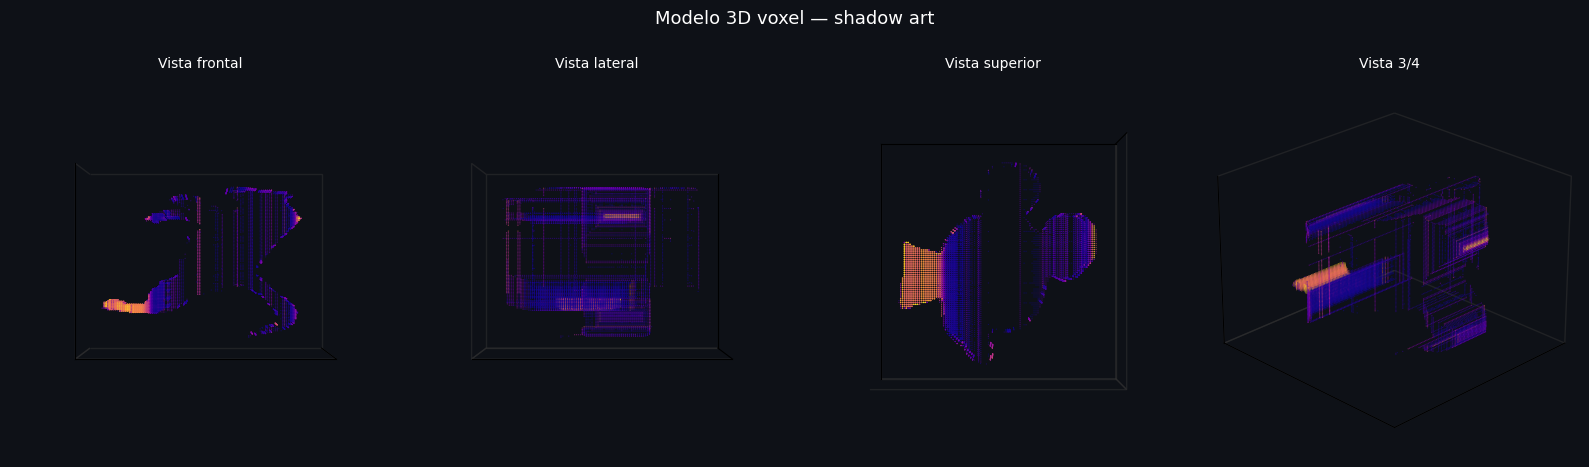

In [6]:
v = np.load("/voxel_results/output1/sample_0_final_voxels.npy")[0]  # (128,128,128)
thresh = 0.3
xs, ys, zs = np.where(v > thresh)
c_norm = (v[xs, ys, zs] - v[xs, ys, zs].min()) / (v[xs, ys, zs].max() - v[xs, ys, zs].min())

fig = plt.figure(figsize=(16, 5))
fig.patch.set_facecolor('#0e1117')

for i, (title, elev, azim) in enumerate([
    ('Vista frontal',   0,  0),
    ('Vista lateral',   0, 90),
    ('Vista superior', 90,  0),
    ('Vista 3/4',      25, 45),
]):
    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    ax.set_facecolor('#0e1117')
    ax.scatter(xs, ys, zs, c=c_norm, cmap='plasma', s=0.8, alpha=0.55, linewidths=0)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(0,128); ax.set_ylim(0,128); ax.set_zlim(0,128)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.grid(False)
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = False
        pane.set_edgecolor('#333333')
    ax.set_title(title, color='white', fontsize=10)

fig.suptitle('Modelo 3D voxel — shadow art', color='white', fontsize=13)
plt.tight_layout()
plt.show()

# Metricas

In [8]:
def compute_all_metrics(folder, num_views, mirror_mode=0):
    results = []

    for idx in range(num_views * (1 + mirror_mode)):
        gt = cv2.imread(
            f"{folder}/sample_0view_{idx}.png", 0
        )
        pred = cv2.imread(
            f"{folder}/sample_0view_{idx}_silh.png", 0
        )

        # Binarización estricta del GT (replica el comportamiento
        # de get_props + threshold que vio el modelo durante training)
        _, gt_bin = cv2.threshold(gt, 127, 255, cv2.THRESH_BINARY)

        # Normalización a [0,1] para que iou_np/dice_np funcionen
        # correctamente (equivalente a operar sobre {0,1})
        gt_norm   = gt_bin  / 255.0
        pred_norm = pred    / 255.0  # ya es {0,255} por el threshold en train()

        # Métricas del paper (iou_np y dice_np del repo)
        iou_val  = iou_np(pred_norm, gt_norm)
        dice_val = dice_np(pred_norm, gt_norm)

        # Métricas adicionales desde la matriz de confusión
        gt_bool   = gt_bin > 0
        pred_bool = pred   > 0

        tp = np.logical_and( gt_bool,  pred_bool).sum()
        fp = np.logical_and(~gt_bool,  pred_bool).sum()
        fn = np.logical_and( gt_bool, ~pred_bool).sum()
        tn = np.logical_and(~gt_bool, ~pred_bool).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 1.0

        # ROI Pixel Accuracy sobre bounding box unión
        roi_acc = _roi_pixel_accuracy(gt_bool, pred_bool, margin=5)

        results.append({
            "view":      idx,
            "IoU":       iou_val,
            "Dice":      dice_val,
            "Precision": precision,
            "Recall":    recall,
            "ROI_PA":    roi_acc,
        })

    return results


def _roi_pixel_accuracy(gt_bool, pred_bool, margin=5):
    def bbox(mask):
        ys, xs = np.where(mask)
        if len(xs) == 0:
            return None
        return xs.min(), xs.max(), ys.min(), ys.max()

    b_gt   = bbox(gt_bool)
    b_pred = bbox(pred_bool)
    if b_gt is None and b_pred is None:
        return 1.0
    b_gt   = b_gt   or b_pred
    b_pred = b_pred or b_gt

    xmin = max(0, min(b_gt[0], b_pred[0]) - margin)
    xmax = min(gt_bool.shape[1]-1, max(b_gt[1], b_pred[1]) + margin)
    ymin = max(0, min(b_gt[2], b_pred[2]) - margin)
    ymax = min(gt_bool.shape[0]-1, max(b_gt[3], b_pred[3]) + margin)

    gt_roi   = gt_bool  [ymin:ymax+1, xmin:xmax+1]
    pred_roi = pred_bool[ymin:ymax+1, xmin:xmax+1]
    return np.mean(gt_roi == pred_roi)

In [9]:
folder = "/voxel_results/output1"
results = compute_all_metrics(folder, num_views)

metrics = ["IoU", "Dice", "Precision", "Recall", "ROI_PA"]
header = f"{'Vista':<8}" + "".join(f"{m:>12}" for m in metrics)
print(header)
print("-" * len(header))
for r in results:
    row = f"{r['view']:<8}" + "".join(f"{r[m]:>12.4f}" for m in metrics)
    print(row)

Vista            IoU        Dice   Precision      Recall      ROI_PA
--------------------------------------------------------------------
0             0.9802      0.9900      0.9994      0.9808      0.9934
1             0.9910      0.9955      1.0000      0.9910      0.9963
